# Laboratorio #4 — Fundamentos de Aprendizaje por Refuerzo y Gymnasium

**Curso:** CC3092 - Deep Learning y Sistemas Inteligentes

**Contenido:**
1. Fundamentos del aprendizaje por refuerzo
2. La librería Gymnasium
3. Módulo de prueba: primeros pasos con Gymnasium
4. Discusión y análisis


## 1. Fundamentos del aprendizaje por refuerzo

### 1.1 ¿Qué es el aprendizaje por refuerzo?

El aprendizaje por refuerzo (RL) es la rama del aprendizaje automático donde un agente aprende a base de probar
cosas dentro de un entorno y ver qué recompensa le da cada decisión, en vez de que alguien le diga de antemano
cuál era la respuesta correcta. Nadie le entrega un dataset con la "mejor acción" para cada situación: el agente
va descubriendo qué funciona por ensayo y error, ajustando su comportamiento según lo que va recibiendo de vuelta.

Comparado con el aprendizaje supervisado la diferencia es justo esa: ahí sí hay un par entrada-salida correcto y
el modelo minimiza el error contra esa etiqueta. En RL no hay tal cosa, solo un número (la recompensa) que además
suele llegar tarde, no inmediatamente después de cada decisión, y que depende de toda una secuencia de acciones,
no de una sola.

Con el no supervisado la diferencia es más sutil porque ninguno de los dos tiene etiquetas. Pero el no supervisado
busca estructura oculta en los datos (agrupar, encontrar patrones); RL sí recibe una señal externa que le dice qué
tan bien le fue, solo que esa señal es evaluativa, no le dice cuál era la acción óptima, nada más qué tan buena
fue la que tomó.


### 1.2 Componentes principales de un problema de RL

Todo problema de RL se puede describir con las mismas piezas:

- Agente: quien aprende y decide.
- Entorno: todo lo demás, con lo que el agente interactúa; recibe la acción y responde con un estado nuevo y una
  recompensa.
- Estado (s): la foto de la situación actual, lo que el agente necesita saber para decidir.
- Acción (a): lo que el agente puede hacer.
- Recompensa (r): el número que indica qué tan bien o mal salió esa transición.
- Política (π): la regla que sigue el agente para elegir acciones a partir de un estado; puede ser una regla fija
  o una distribución de probabilidad.

El ciclo básico es: el agente ve el estado s_t, elige una acción a_t con su política, el entorno pasa a un estado
s_{t+1} y devuelve una recompensa r_{t+1}, y con eso el agente ajusta (o no) su política para la próxima vez.


### 1.3 Proceso de Decisión de Markov (MDP)

Un MDP es la forma matemática de modelar un problema de RL cuando el entorno es completamente observable. Se
describe con la tupla (S, A, P, R, γ):

- S, el conjunto de estados posibles.
- A, el conjunto de acciones posibles.
- P(s'|s,a), la función de transición: la probabilidad de terminar en s' si estando en s se ejecuta a. Cumple la
  propiedad de Markov, es decir que a dónde se va después solo depende del estado y la acción actuales, no de
  cómo se llegó ahí.
- R(s,a,s'), la recompensa esperada al pasar de s a s' con la acción a.
- γ (gamma), el factor de descuento, entre 0 y 1, que pesa cuánto importa una recompensa futura frente a una
  inmediata. Con γ cerca de 0 el agente casi solo mira el corto plazo; con γ cerca de 1 le da casi el mismo peso
  a recompensas lejanas que a las inmediatas.


### 1.4 Función de valor V(s) y función de valor acción-estado Q(s,a)

V(s) es el retorno esperado (la suma de recompensas futuras, descontadas por γ) si el agente arranca en el
estado s y de ahí en adelante sigue la política π:

V^π(s) = E_π [ Σ_{k=0}^{∞} γ^k r_{t+k+1} | s_t = s ]

Q(s,a) es prácticamente lo mismo pero fijando también la primera acción: el retorno esperado si el agente está en
s, toma la acción a, y luego sigue π:

Q^π(s,a) = E_π [ Σ_{k=0}^{∞} γ^k r_{t+k+1} | s_t = s, a_t = a ]

En el fondo ambas responden la misma pregunta, "qué tan bueno es esto", solo que Q lo hace por cada par
estado-acción en vez de solo por estado. Y eso es justo lo que las hace útiles: la política óptima es la que en
cada estado elige la acción con mayor Q, π*(s) = argmax_a Q*(s,a). Si uno ya tiene Q*, no necesita saber nada más
del entorno (ni su función de transición) para actuar de forma óptima, que es la idea detrás de métodos
model-free como Q-Learning.


### 1.5 Ecuación de Bellman

La ecuación de Bellman es la que conecta el valor de un estado con el valor de los estados a los que se puede
llegar desde ahí. La idea, dicho simple, es que el valor de estar en un estado es la recompensa que se espera
recibir de inmediato más el valor (descontado) del estado al que se llega después.

Para V(s):

V^π(s) = Σ_a π(a|s) Σ_{s'} P(s'|s,a) [ R(s,a,s') + γ V^π(s') ]

Y de forma parecida para Q(s,a):

Q^π(s,a) = Σ_{s'} P(s'|s,a) [ R(s,a,s') + γ Σ_{a'} π(a'|s') Q^π(s',a') ]

Lo que hace útil esta ecuación es que convierte algo que en principio requeriría sumar una secuencia infinita de
recompensas en una ecuación que se puede resolver por partes, de forma iterativa (programación dinámica, Monte
Carlo, o TD-learning como Q-Learning). Cuando se escribe para la política óptima se le llama ecuación de
optimalidad de Bellman, y de ahí salen algoritmos como Value Iteration o el propio Q-Learning.


### 1.6 Exploración vs. explotación

Este dilema aparece porque en cada paso el agente tiene que elegir entre explotar, es decir tomar la acción que
según lo que sabe hasta ahora le da mejor recompensa, o explorar, probar algo distinto aunque parezca peor sobre
el papel, solo para ver qué pasa y tener más información. Si solo explota corre el riesgo de quedarse pegado en
una solución que no es la mejor simplemente porque nunca probó otra cosa; si solo explora, nunca usa lo que ya
aprendió y su desempeño no mejora.

Dos formas típicas de manejar esto:

- Epsilon-greedy: con probabilidad ε se toma una acción al azar y con probabilidad 1-ε se toma la mejor acción
  conocida. Normalmente ε se va reduciendo con el tiempo para explorar más al inicio y explotar más después.
- Softmax o Boltzmann: en vez de un corte duro, se eligen las acciones con una probabilidad proporcional a su
  valor Q, controlada por una temperatura. Con temperatura alta casi todas las acciones tienen chance parecida
  (más exploración); con temperatura baja casi siempre gana la mejor acción conocida.


### 1.7 Tareas episódicas vs. continuas; on-policy vs. off-policy; model-based vs. model-free

Episódicas vs. continuas: una tarea episódica tiene un final, un estado terminal, y la interacción se corta en
"episodios" (CartPole por ejemplo termina cuando el poste se cae). El retorno ahí es una suma finita. Una tarea
continua no tiene ese final natural, la interacción sigue indefinidamente, y por eso se necesita γ<1 para que la
suma de recompensas no se vaya a infinito.

On-policy vs. off-policy: un método on-policy aprende sobre la misma política que está usando para actuar, como
SARSA. Uno off-policy, como Q-Learning, puede aprender sobre una política distinta (la óptima) mientras actúa con
otra (una exploratoria, tipo ε-greedy), porque separa la política que genera los datos de la que está aprendiendo.

Model-based vs. model-free: en model-based el agente cuenta con (o construye) un modelo de cómo funciona el
entorno, es decir P y R, y lo usa para planear antes de actuar. En model-free no hay tal modelo, el agente
aprende directamente de la experiencia qué tan buenas son las acciones, sin intentar predecir cómo se comporta el
entorno. Q-Learning y SARSA caen en esta segunda categoría.


### 1.8 Q-Learning

Q-Learning es el algoritmo model-free y off-policy más clásico para aprender Q(s,a) directamente de la
experiencia, sin necesidad de un modelo del entorno. Se actualiza así:

Q(s_t, a_t) <- Q(s_t, a_t) + α [ r_{t+1} + γ · max_a Q(s_{t+1}, a) - Q(s_t, a_t) ]

α es la tasa de aprendizaje: qué tanto se mueve la estimación actual de Q hacia lo que se acaba de observar. Con
α alto el agente le da mucho peso a la última observación (aprende rápido pero es más ruidoso); con α bajo el
ajuste es más lento pero más estable. γ es el mismo factor de descuento de siempre, y aquí determina cuánto pesa
el mejor valor futuro estimado al actualizar el par actual. Lo interesante es que se usa el máximo sobre las
acciones del siguiente estado, no la acción que realmente se va a tomar después; eso es justo lo que hace que el
método sea off-policy, porque aprende sobre la política óptima aunque esté actuando con otra (por ejemplo una
ε-greedy). Con suficientes visitas a cada par (s,a) y un α que decaiga adecuadamente, se puede demostrar que
converge a Q*.


## 2. La librería Gymnasium

### 2.1 ¿Qué es Gymnasium?

Gymnasium es una librería de Python mantenida por la Farama Foundation que da una API común para definir y usar
entornos de RL. Es, básicamente, la continuación de OpenAI Gym, la librería original de 2016 que fue la primera
en popularizar ese patrón de `reset()`/`step()` que hoy casi todo el mundo usa. Cuando OpenAI dejó de darle
mantenimiento activo a Gym, la Farama Foundation tomó el proyecto en 2021, lo bifurcó y lo siguió desarrollando
bajo el nombre de Gymnasium: mismo estilo de API, pero con bugs corregidos, mejor tipado, y una forma más clara
de indicar por qué terminó un episodio (separando `terminated` de `truncated`).

El problema de fondo que resuelve es que, antes de que existiera algo como Gym, cada quien programaba sus propios
entornos con su propia interfaz, y comparar dos algoritmos entrenados en entornos distintos era un dolor de
cabeza. Con una interfaz uniforme (`Env`, `Space`, `reset`, `step`) cualquier agente que sepa hablar esa API
puede entrenarse en cualquier entorno compatible, sin que importe qué tan complicado sea por dentro.


### 2.2 Estructura básica de un entorno (`Env`)

Cualquier entorno de Gymnasium hereda de `gymnasium.Env` y expone estos métodos:

`reset(seed=None, options=None)` reinicia el entorno y arranca un episodio nuevo. Devuelve `(observation, info)`:
la observación es el primer estado que ve el agente (con la forma que dicta `observation_space`), e `info` es un
diccionario con datos extra que sirven más para diagnóstico que para que el agente decida algo con ellos.

`step(action)` recibe una acción y avanza un paso. Devuelve cinco cosas: `(observation, reward, terminated,
truncated, info)`. La observación es el estado nuevo, `reward` es la recompensa de ese paso, `terminated` es
`True` cuando el episodio se acabó por una razón que tiene que ver con el MDP en sí (el poste de CartPole se cayó,
por ejemplo), y `truncated` es `True` cuando se cortó por algo externo, normalmente un límite de pasos impuesto
por un wrapper `TimeLimit`, no porque el entorno haya llegado a un estado terminal de verdad.

`render()` genera algo visual del estado actual (una imagen, una ventana), y `close()` libera lo que el entorno
haya usado, como procesos o ventanas abiertas.


### 2.3 Espacios de observación y acción (`Spaces`)

Los `Spaces` definen qué valores son válidos para las observaciones y las acciones de un entorno. Los tres que
más se usan:

`Discrete(n)` es un conjunto finito de enteros, del 0 al n-1. Aparece en entornos con acciones o estados
categóricos: las 2 acciones de CartPole (empujar a la izquierda o a la derecha), o las 16 celdas posibles en
FrozenLake 4x4.

`Box(low, high, shape, dtype)` es un espacio continuo de n dimensiones, cada una con su propio límite inferior y
superior. Se usa cuando la observación o la acción son números reales, por ejemplo la posición y velocidad del
carro en CartPole.

`MultiDiscrete([n1, n2, ...])` es varias variables discretas juntas, cada una con su propio rango, combinadas en
un solo vector de acción. Sirve para acciones compuestas, como controlar a la vez varios botones o ejes discretos
de un control, algo común en ciertos entornos de Atari.


### 2.4 Catálogo de entornos de Gymnasium

Gymnasium agrupa sus entornos en familias como Classic Control, Box2D y Toy Text. De ahí elegí 4 para revisar:

**CartPole-v1** (Classic Control). Hay que mantener un poste en equilibrio arriba de un carro que se mueve sobre
un riel, sin dejar que se caiga ni que el carro se salga de los límites. La observación es `Box(4,)`: posición del
carro, su velocidad, ángulo del poste y velocidad angular del poste. La acción es `Discrete(2)`, empujar a la
izquierda o a la derecha.

**MountainCar-v0** (Classic Control). Un auto queda atrapado en un valle y hay que llevarlo hasta la cima de la
derecha, pero el motor no alcanza para subir de frente, así que hay que ganar impulso yendo y viniendo.
Observación `Box(2,)` con posición y velocidad; acción `Discrete(3)`: acelerar a la izquierda, no acelerar, o
acelerar a la derecha.

**FrozenLake-v1** (Toy Text). Cruzar una grilla que representa un lago congelado, desde el inicio hasta la meta,
sin caer en algún hoyo, y con la superficie potencialmente resbaladiza (las transiciones pueden ser estocásticas).
Observación `Discrete(16)` en la versión 4x4 (el índice de la celda donde está el agente); acción `Discrete(4)`:
moverse izquierda, abajo, derecha o arriba.

**LunarLander-v3** (Box2D). Aterrizar una nave entre dos banderas controlando los motores, sin estrellarse ni
tocar con demasiada velocidad o ángulo. Observación `Box(8,)`: posición, velocidad, ángulo, velocidad angular y
dos valores booleanos que indican si cada pata está tocando el suelo. Acción `Discrete(4)`: no hacer nada, motor
izquierdo, motor principal, o motor derecho.


### 2.5 Wrappers en Gymnasium

Un wrapper envuelve un entorno para agregarle o cambiarle comportamiento sin tocar el código del entorno
original. Implementa la misma interfaz que `Env` (reset, step, etc.), simplemente delega al entorno de adentro y
mete lógica extra antes o después. Así se pueden ir apilando funcionalidades sin ensuciar nada.

Algunos ejemplos que se usan seguido: `TimeLimit` pone un tope de pasos por episodio, y cuando se llega a ese
tope marca `truncated=True` aunque el episodio en sí no haya terminado de forma natural (de hecho la mayoría de
entornos ya vienen con este wrapper puesto por defecto cuando se llama `gym.make()`). `RecordVideo` graba los
episodios como video usando `render_mode="rgb_array"`, útil para revisar después qué hizo el agente sin tener que
ver todo en vivo. Y están los wrappers de normalización de observaciones, que reescalan los valores (por ejemplo
a media 0 y varianza 1) para que el entrenamiento sea más estable.


## 3. Módulo de prueba: primeros pasos con Gymnasium

### 3.1 Instalación y verificación de la versión de Gymnasium

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print("Versión de gymnasium instalada:", gym.__version__)


Versión de gymnasium instalada: 1.3.0


### 3.2 Instancia de CartPole-v1: espacios de observación y acción

In [2]:
env = gym.make("CartPole-v1")

print("=== CartPole-v1 ===")
print("\nEspacio de observación:", env.observation_space)
print("  Tipo:", type(env.observation_space).__name__)
print("  Dimensión (shape):", env.observation_space.shape)
print("  Límites inferiores:", env.observation_space.low)
print("  Límites superiores:", env.observation_space.high)

print("\nEspacio de acción:", env.action_space)
print("  Tipo:", type(env.action_space).__name__)
print("  Número de acciones:", env.action_space.n)

env.close()


=== CartPole-v1 ===

Espacio de observación: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  Tipo: Box
  Dimensión (shape): (4,)
  Límites inferiores: [-4.8               -inf -0.41887903        -inf]
  Límites superiores: [4.8               inf 0.41887903        inf]

Espacio de acción: Discrete(2)
  Tipo: Discrete
  Número de acciones: 2


Las 4 dimensiones de la observación de CartPole-v1 son, en orden: **posición del carro**, **velocidad del
carro**, **ángulo del poste** (radianes) y **velocidad angular del poste**. El espacio de acción es discreto con
2 valores posibles: `0` (empujar a la izquierda) y `1` (empujar a la derecha).

### 3.3 Agente aleatorio en CartPole-v1 (5+ episodios)

In [3]:
def run_random_agent(env_name, n_episodes=5, seed=0, **make_kwargs):
    """Ejecuta un agente que toma acciones aleatorias y registra steps/return por episodio."""
    env = gym.make(env_name, **make_kwargs)
    steps_per_episode = []
    returns_per_episode = []

    for ep in range(n_episodes):
        observation, info = env.reset(seed=seed + ep)
        terminated = truncated = False
        steps = 0
        total_reward = 0.0

        while not (terminated or truncated):
            action = env.action_space.sample()
            observation, reward, terminated, truncated, info = env.step(action)
            steps += 1
            total_reward += reward

        steps_per_episode.append(steps)
        returns_per_episode.append(total_reward)
        print(f"Episodio {ep + 1}: steps = {steps:4d} | return = {total_reward:.2f}")

    env.close()
    return steps_per_episode, returns_per_episode


print("=== Agente aleatorio: CartPole-v1 ===")
cartpole_random_steps, cartpole_random_returns = run_random_agent("CartPole-v1", n_episodes=5)
print(f"\nPromedio de return: {np.mean(cartpole_random_returns):.2f}")


=== Agente aleatorio: CartPole-v1 ===
Episodio 1: steps =   20 | return = 20.00
Episodio 2: steps =   14 | return = 14.00
Episodio 3: steps =   27 | return = 27.00
Episodio 4: steps =   16 | return = 16.00
Episodio 5: steps =   13 | return = 13.00

Promedio de return: 18.00


### 3.4 Gráfica de recompensa por episodio — Agente aleatorio en CartPole-v1

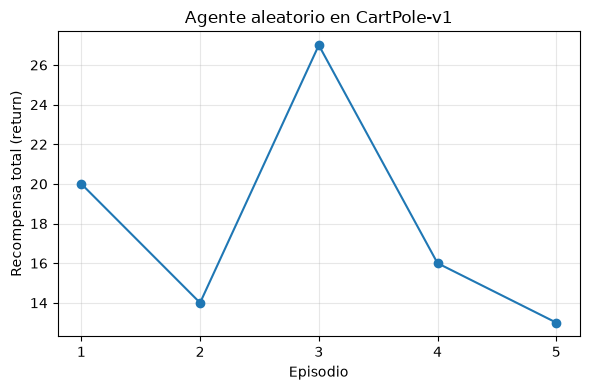

In [4]:
plt.figure(figsize=(6, 4))
episodes = range(1, len(cartpole_random_returns) + 1)
plt.plot(episodes, cartpole_random_returns, marker="o", color="tab:blue")
plt.xlabel("Episodio")
plt.ylabel("Recompensa total (return)")
plt.title("Agente aleatorio en CartPole-v1")
plt.xticks(list(episodes))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cartpole_random_returns.png", dpi=150)
plt.show()


### 3.5 Agente aleatorio en un segundo entorno discreto: FrozenLake-v1

Se eligió **FrozenLake-v1** (grilla 4x4, `is_slippery=True` por defecto) como segundo entorno discreto para
comparar con CartPole-v1. A diferencia de CartPole, FrozenLake tiene un espacio de observación **discreto**
(`Discrete(16)`, un índice de celda) y una recompensa **muy dispersa** (sparse): 0 en cada paso, y +1 solo si el
agente alcanza la meta.

In [5]:
env = gym.make("FrozenLake-v1")
print("=== FrozenLake-v1 ===")
print("Espacio de observación:", env.observation_space)
print("Espacio de acción:", env.action_space)
env.close()

print("\n=== Agente aleatorio: FrozenLake-v1 ===")
frozenlake_random_steps, frozenlake_random_returns = run_random_agent("FrozenLake-v1", n_episodes=5)
print(f"\nPromedio de return: {np.mean(frozenlake_random_returns):.2f}")
print(f"Episodios exitosos (return > 0): {sum(r > 0 for r in frozenlake_random_returns)} / {len(frozenlake_random_returns)}")


=== FrozenLake-v1 ===
Espacio de observación: Discrete(16)
Espacio de acción: Discrete(4)

=== Agente aleatorio: FrozenLake-v1 ===
Episodio 1: steps =    4 | return = 0.00
Episodio 2: steps =    6 | return = 0.00
Episodio 3: steps =   22 | return = 0.00
Episodio 4: steps =    5 | return = 0.00
Episodio 5: steps =   15 | return = 0.00

Promedio de return: 0.00
Episodios exitosos (return > 0): 0 / 5


### 3.6 Comparación de comportamiento: CartPole-v1 vs. FrozenLake-v1 (agente aleatorio)

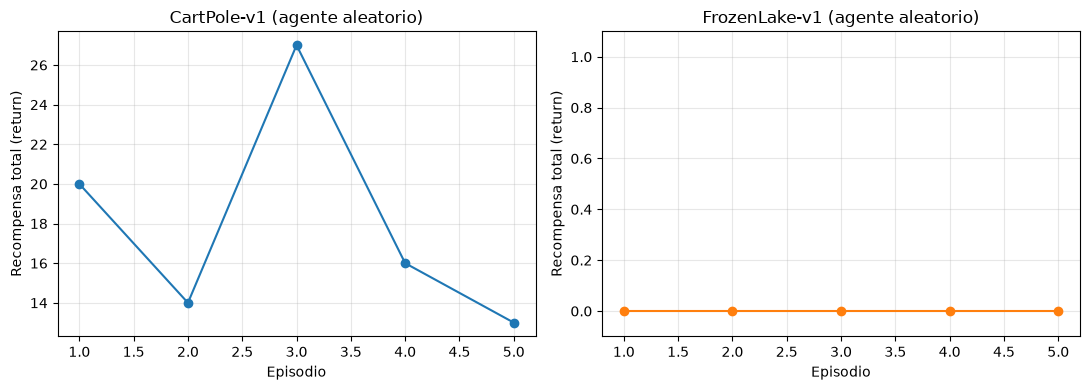

Resumen comparativo (agente aleatorio, 5 episodios):
  CartPole-v1   -> steps promedio: 18.0 | return promedio: 18.00
  FrozenLake-v1 -> steps promedio: 10.4 | return promedio: 0.00


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(range(1, len(cartpole_random_returns) + 1), cartpole_random_returns, marker="o", color="tab:blue")
axes[0].set_title("CartPole-v1 (agente aleatorio)")
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel("Recompensa total (return)")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(frozenlake_random_returns) + 1), frozenlake_random_returns, marker="o", color="tab:orange")
axes[1].set_title("FrozenLake-v1 (agente aleatorio)")
axes[1].set_xlabel("Episodio")
axes[1].set_ylabel("Recompensa total (return)")
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("comparacion_random_agent.png", dpi=150)
plt.show()

print("Resumen comparativo (agente aleatorio, 5 episodios):")
print(f"  CartPole-v1   -> steps promedio: {np.mean(cartpole_random_steps):.1f} | return promedio: {np.mean(cartpole_random_returns):.2f}")
print(f"  FrozenLake-v1 -> steps promedio: {np.mean(frozenlake_random_steps):.1f} | return promedio: {np.mean(frozenlake_random_returns):.2f}")


En CartPole-v1 el agente aleatorio de todos modos consigue algo de recompensa en cada episodio, porque
recibe 1 punto por cada paso que el poste sigue en pie, aunque se cae rápido al no lograr mantener el equilibrio
por mucho tiempo. En FrozenLake casi nunca llega a la meta: la recompensa es 0 en la mayoría de episodios, porque
la chance de que una secuencia aleatoria de movimientos sea justo la correcta (y encima en un entorno estocástico
por el hielo resbaladizo) es bajísima. Se nota bien cómo el tipo de recompensa, densa o dispersa, cambia por
completo qué tan útil resulta actuar al azar.

### 3.7 Política simple (no aprendida) para CartPole-v1

Se implementa la heurística sugerida: *"si la velocidad angular del poste (observación índice 3) es positiva,
empujar a la derecha; si es negativa, empujar a la izquierda"*.

In [7]:
def simple_policy(observation):
    """Política heurística basada en la velocidad angular del poste."""
    pole_angular_velocity = observation[3]
    return 1 if pole_angular_velocity > 0 else 0


def run_policy_agent(env_name, policy_fn, n_episodes=5, seed=100, **make_kwargs):
    env = gym.make(env_name, **make_kwargs)
    steps_per_episode = []
    returns_per_episode = []

    for ep in range(n_episodes):
        observation, info = env.reset(seed=seed + ep)
        terminated = truncated = False
        steps = 0
        total_reward = 0.0

        while not (terminated or truncated):
            action = policy_fn(observation)
            observation, reward, terminated, truncated, info = env.step(action)
            steps += 1
            total_reward += reward

        steps_per_episode.append(steps)
        returns_per_episode.append(total_reward)
        print(f"Episodio {ep + 1}: steps = {steps:4d} | return = {total_reward:.2f}")

    env.close()
    return steps_per_episode, returns_per_episode


print("=== Política simple (velocidad angular): CartPole-v1 ===")
cartpole_policy_steps, cartpole_policy_returns = run_policy_agent("CartPole-v1", simple_policy, n_episodes=5)
print(f"\nPromedio de return: {np.mean(cartpole_policy_returns):.2f}")


=== Política simple (velocidad angular): CartPole-v1 ===
Episodio 1: steps =  206 | return = 206.00
Episodio 2: steps =  233 | return = 233.00
Episodio 3: steps =  189 | return = 189.00
Episodio 4: steps =  171 | return = 171.00
Episodio 5: steps =  187 | return = 187.00

Promedio de return: 197.20


### 3.8 Comparación: agente aleatorio vs. política simple en CartPole-v1

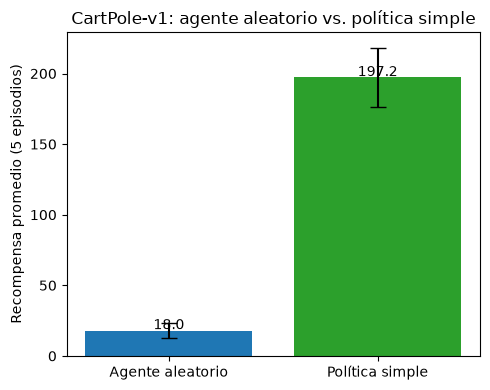

Resumen final:
  Agente aleatorio -> return promedio: 18.00 (+/- 5.10)
  Política simple  -> return promedio: 197.20 (+/- 21.06)
  Diferencia (política simple - aleatorio): +179.20


In [8]:
labels = ["Agente aleatorio", "Política simple"]
means = [np.mean(cartpole_random_returns), np.mean(cartpole_policy_returns)]
stds = [np.std(cartpole_random_returns), np.std(cartpole_policy_returns)]

plt.figure(figsize=(5, 4))
bars = plt.bar(labels, means, yerr=stds, capsize=6, color=["tab:blue", "tab:green"])
plt.ylabel("Recompensa promedio (5 episodios)")
plt.title("CartPole-v1: agente aleatorio vs. política simple")
for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{mean:.1f}", ha="center")
plt.tight_layout()
plt.savefig("comparacion_random_vs_policy.png", dpi=150)
plt.show()

print("Resumen final:")
print(f"  Agente aleatorio -> return promedio: {means[0]:.2f} (+/- {stds[0]:.2f})")
print(f"  Política simple  -> return promedio: {means[1]:.2f} (+/- {stds[1]:.2f})")
mejora = means[1] - means[0]
print(f"  Diferencia (política simple - aleatorio): {mejora:+.2f}")


## 4. Discusión y análisis

**Diferencias entre el agente aleatorio en CartPole-v1 y en FrozenLake-v1.** En CartPole el agente
aleatorio saca recompensas moderadas y bastante variables episodio a episodio, algo así entre 10 y 40 puntos
dependiendo de la semilla, porque recibe +1 por cada paso que sobrevive y el entorno tiene recompensa densa:
cualquier secuencia de acciones ya suma algo antes de que el poste termine cayéndose. En FrozenLake el resultado
fue distinto, el agente aleatorio se quedó en 0 en prácticamente todos los episodios que corrí. Tiene sentido: la
recompensa ahí solo aparece al llegar a la meta (+1, y nada más), y encima el piso resbaladizo hace que las
transiciones no sean ni siquiera determinísticas, así que la chance de que 4 movimientos al azar terminen
llevando a la meta es mínima. En el fondo esto tiene que ver con qué tan densa es la recompensa de cada entorno:
CartPole te va dando pistas en cada paso, FrozenLake casi no te dice nada hasta que por fin (o nunca) llegás.

**¿La política simple le ganó al agente aleatorio?** Sí, y por bastante (se puede ver en la sección 3.8). Una
regla tan simple como "empujar hacia donde se está inclinando el poste" ya alcanza para sostenerlo mucho más
tiempo que actuar al azar. Lo que me parece interesante de esto es que con solo un poco de conocimiento del
problema —sin entrenar nada— ya se saca una ventaja enorme. Eso no quiere decir que esta regla sea la mejor
posible: solo usa una de las cuatro variables del estado, así que una política que sí aprenda (con Q-Learning,
por ejemplo) probablemente la termine superando al aprovechar toda la información disponible. Pero como punto de
partida, o como comparación base, deja claro que el conocimiento del dominio vale mucho cuando no se tiene nada
más.

**¿Por qué explorar si ya se tiene una política que funciona bien?** Porque "funciona bien" no es lo mismo que
"es óptima". Puede que la política actual esté fallando justo en los estados que casi nunca visita, y si nunca se
prueba nada distinto ahí, nunca se va a saber si había una acción mejor. Ese es el dilema de siempre: quedarse
con lo conocido da resultados aceptables de inmediato, pero deja pasar la posibilidad de encontrar algo mejor, o
de darse cuenta de que el entorno cambió. Por eso estrategias como ε-greedy no bajan la exploración a cero ni
siquiera cuando la política ya parece buena, sino que dejan una fracción pequeña de las decisiones para seguir
probando.

**¿Cuál de los entornos vistos parece más interesante para un laboratorio futuro?** Me quedo con LunarLander-v3.
Tiene una observación continua de 8 dimensiones y una acción discreta de 4, así que es un salto de complejidad
importante respecto a CartPole sin volverse inmanejable, y se presta tanto para métodos tabulares con
discretización como para algo más natural, como Deep Q-Networks. Además su recompensa combina varios factores
(gasto de combustible, qué tan suave fue el aterrizaje, etc.), lo que abriría la puerta a jugar con reward
shaping y con algoritmos que ya se acerquen más a lo que se ve en un curso de Deep Learning.
